# BB84

We are going to use Qiskit to simulate the BB84 protocol

We will use the circuit from our previous notebook to generate random bits

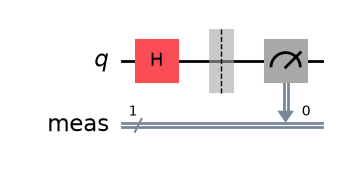

In [1]:
%matplotlib inline

from qiskit import QuantumCircuit

qc_random = QuantumCircuit(1) # We need qubit

qc_random.h(0) #We apply the H gate

qc_random.measure_all() # Measure

qc_random.draw('mpl');

In [12]:
# Executing on the local simulator
from qiskit.primitives import StatevectorSampler

n = 100 # Number of bits that we are going to use

# Create simulator sampler
sampler = StatevectorSampler()

# Alice generates n random bits
job_1 = sampler.run(
    [qc_random],
    shots=n
)
result = job_1.result()
memory = result[0].data.meas.get_bitstrings()  # Extract individual measurement results
bits_alice = [int(q) for q in memory]  # Convert strings ('0'/'1') into integers

# Alice randomly chooses the bases in which she is going to measure
job_2 = sampler.run(
    [qc_random],
    shots=n
)
result = job_2.result()
memory = result[0].data.meas.get_bitstrings()
basis_alice = [int(q) for q in memory]

# Bob also chooses at random the bases in which he will measure
job_3 = sampler.run(
    [qc_random],
    shots=n
)
result = job_3.result()
memory = result[0].data.meas.get_bitstrings()
basis_bob = [int(q) for q in memory]


print("bits_alice:",bits_alice)
print("basis_alice:", basis_alice)
print("basis_bob:", basis_bob)

bits_alice: [0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]
basis_alice: [1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0]
basis_bob: [0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0]


In [13]:
# Now, Alice codes each bit of her initial string as a qubit and sends it to Bob, who measures in his basis
bits_bob_sim = []

for i in range(n):
    qc_send = QuantumCircuit(1,1)

    # Alice has to send '1'.  Python treats 0 as False.
    # if Alice's bit is 1 flip the qubit from |0⟩ to |1⟩ otherwise leave it as |0⟩
    if bits_alice[i]: 
        qc_send.x(0)
    if basis_alice[i]: # Alice codes in basis |+>, |->
        qc_send.h(0)
        
    # Alice sends the qubit to Bob and he measures
    if basis_bob[i]: # Bob has to measure in basis |+>, |->
        qc_send.h(0) 
    
    qc_send.measure(0,0)
    
    job = sampler.run(
        [qc_send],   # [qc_send] one circuit, one job per qubit
        shots=1
    )

    result = job.result()
    
    # Get Bob's individual measurement result
    bit = result[0].data.c.get_bitstrings()[0]
    bits_bob_sim.append(int(bit))

print(bits_bob_sim)    

[0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0]


In [14]:
# Bob tells Alice the basis he used for his measurements 
# Alice confirms which of the basis are correct

key_sim = []

for i in range(n):
    if basis_alice[i] == basis_bob[i]:
        key_sim.append(bits_bob_sim[i])
        
print("Key length", len(key_sim))
print(key_sim)

Key length 61
[1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]


In [5]:
# Connecting to the real quantum computers
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)



In [6]:
service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True,
    simulator=False
)

qiskit_runtime_service.__init__:WARNING:2026-08-21 00:47:43,144: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-08-21 00:47:43,660: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-08-21 00:47:47,671: Using instance: open-instance, plan: open


In [ ]:
# Create BB84 circuits
circuits = []

n = 100 # Number of bits that we are going to use
for i in range(n):
    qc = QuantumCircuit(1,1)

    if bits_alice[i]:
        qc.x(0)
    if basis_alice[i]:
        qc.h(0)
    if basis_bob[i]:
        qc.h(0)

    qc.measure(0,0)

    circuits.append(qc)

# Run on real quantum computer
sampler = Sampler(mode=backend)

# Convert to hardware-compatible circuits
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)
isa_circuits = pm.run(circuits)

job_exp = sampler.run(
    isa_circuits,  # many circuits stored in a list, one job for all qubits
    shots=1
)

result_exp = job_exp.result()

# Bob's measurements
bits_bob_exp = []

for i in range(n):
    bit_exp = result_exp[i].data.c.get_bitstrings()[0]
    bits_bob_exp.append(int(bit_exp))

print(bits_bob_exp)

[1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1]


In [15]:
key_exp = []

for i in range(n):
    if basis_alice[i] == basis_bob[i]:
        key_exp.append(bits_bob_exp[i])
        
print("Key length", len(key_exp))
print(key_exp)

Key length 61
[1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1]
